# ERCOT Electricity Demand Forecasting  
## Notebook 01: Data Ingestion and Validation

This notebook performs:
- API-based data ingestion from the U.S. Energy Information Administration (EIA)
- Schema validation and data quality checks
- Transformation from long to wide format
- Time index validation and continuity checks
- Daily aggregation with hourly coverage diagnostics

The resulting datasets are used for downstream time series analysis and forecasting.

---

## Data Ingestion Note

Data is retrieved from the EIA API.

To fetch fresh data:
1. Provide your API key using environment variables or Colab secrets  
2. Uncomment the API ingestion section in this notebook  

By default, this notebook loads a previously saved dataset to ensure reproducibility and ease of execution.

## 1. Setup & Imports

In [1]:
# Import libraries
import requests
import time
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Define Project Paths

In [2]:
# Validate path
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand')
print(os.getcwd())

/content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand


In [3]:
# Define base path
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand")

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FEATURES_DIR = BASE_DIR / "data" / "features"

for folder in [RAW_DIR, PROCESSED_DIR, FEATURES_DIR]:
  folder.mkdir(parents= True, exist_ok= True)

print("Directories ready.")

Directories ready.


## 3. Load API Key from Colab Secrets

In [4]:
# # Getting API key from secret key saved in colab
# from google.colab import userdata
# API_KEY = userdata.get('EIA_API_KEY')

## 4. Configure EIA API Request Parameters

In [5]:
# import requests
# import pandas as pd
# import time

# BASE_URL = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

# params = {
#     "api_key": API_KEY,
#     "frequency": "hourly",
#     "data[0]": "value",
#     "facets[respondent][]": "ERCO",
#     "facets[type][]": ["D", "DF", "NG"],
#     "start": "2019-01-01T00",
#     "end": "2026-03-27T00",
#     "sort[0][column]": "period",
#     "sort[0][direction]": "desc",
#     "offset": 0,
#     "length": 5000
# }

## 5. Fetch Data from API (Paginated)

In [6]:
# def fetch_eia_paginated(base_url, params):
#   working_params = params.copy()
#   all_rows = []

#   while True:
#       response = requests.get(base_url, params=working_params, timeout=60)
#       response.raise_for_status()
#       data = response.json()

#       rows = data.get("response", {}).get("data", [])

#       if not rows:
#           break

#       all_rows.extend(rows)

#       if len(rows) < working_params["length"]:
#           break

#       working_params["offset"] += working_params["length"]
#       time.sleep(0.15)

#   return pd.DataFrame(all_rows)


# df_raw = fetch_eia_paginated(BASE_URL, params)

# print("Raw shape:", df_raw.shape)
# df_raw.head()

## 6. Save Raw Dataset

In [7]:
# # Store paginated row data
# raw_file = RAW_DIR/"ercot_hourly_raw.csv"
# df_raw.to_csv(raw_file, index = False)

### 7. Reload Raw Dataset

In [8]:
raw_file = RAW_DIR / "ercot_hourly_raw.csv"
df_raw = pd.read_csv(raw_file)
print(df_raw.shape)
df_raw.head()

(190154, 7)


,period,respondent,respondent-name,type,type-name,value,value-units
0,2026-03-27T00,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,65117,megawatthours
1,2026-03-27T00,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,65395,megawatthours
2,2026-03-27T00,ERCO,"Electric Reliability Council of Texas, Inc.",NG,Net generation,65116,megawatthours
3,2026-03-26T23,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,66181,megawatthours
4,2026-03-26T23,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,66404,megawatthours


## 8. Column Names Validation & Standardization

In [9]:
# Assign dataset to df & Check on dataset
df = df_raw.copy()
df.columns

Index(['period', 'respondent', 'respondent-name', 'type', 'type-name', 'value',
       'value-units'],
      dtype='object')

In [10]:
# Standardize column names
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print(df.columns.tolist())

['period', 'respondent', 'respondent_name', 'type', 'type_name', 'value', 'value_units']


## 9. Schema Validation

In [11]:
required_columns = [
    "period",
    "respondent",
    "type",
    "value"
]

missing_columns = set(required_columns) - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Schema validation passed.")

Schema validation passed.


## 10. Data Type Conversion

In [12]:
# Check on data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190154 entries, 0 to 190153
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   period           190154 non-null  object
 1   respondent       190154 non-null  object
 2   respondent_name  190154 non-null  object
 3   type             190154 non-null  object
 4   type_name        190154 non-null  object
 5   value            190154 non-null  int64 
 6   value_units      190154 non-null  object
dtypes: int64(1), object(6)
memory usage: 10.2+ MB


In [13]:
df["period"] = pd.to_datetime(df["period"])
df["value"] = pd.to_numeric(df["value"])

print(df.dtypes)

period             datetime64[ns]
respondent                 object
respondent_name            object
type                       object
type_name                  object
value                       int64
value_units                object
dtype: object


## 11. Null Check on Key Fields

In [14]:
print("Null counts in key fields:")
print(df[["period", "respondent", "type", "value"]].isnull().sum())

if df["period"].isnull().any():
    raise ValueError("Null values found in period after datetime conversion.")

if df["value"].isnull().any():
    raise ValueError("Null values found in value after numeric conversion.")

print("Key field null checks passed.")

Null counts in key fields:
period        0
respondent    0
type          0
value         0
dtype: int64
Key field null checks passed.


## 12. Domain Validation Checks

In [15]:
# Validate every type values
print("Types:", df["type"].unique())

assert set(df["type"].unique()).issubset({"D", "DF", "NG"})
assert (df["value"] >= 0).all()

print("Domain checks passed.")

Types: ['D' 'DF' 'NG']
Domain checks passed.


In [16]:
(df["value"] >= 0).all()

np.True_

## 13. Duplicate Check

In [17]:
duplicates = df.duplicated(subset=["period", "type"]).sum()
print("Duplicate rows:", duplicates)


Duplicate rows: 0


## 14. Transform Data: Long to Wide Format (Pivot)

In [18]:
df_hourly = (
    df.pivot_table(
        index="period",
        columns="type",
        values="value",
        aggfunc="first"
    )
    .rename(columns={
        "D": "demand",
        "DF": "demand_forecast",
        "NG": "net_generation"
    })
    .reset_index()
    .sort_values("period")
    .reset_index(drop= True)
)

print("Hourly wide shape:", df_hourly.shape)
df_hourly.head()

Hourly wide shape: (63409, 4)


type,period,demand,demand_forecast,net_generation
0,2019-01-01 00:00:00,38397.0,37423.0,38197.0
1,2019-01-01 01:00:00,40387.0,39839.0,40282.0
2,2019-01-01 02:00:00,39769.0,39159.0,39783.0
3,2019-01-01 03:00:00,39016.0,38407.0,39032.0
4,2019-01-01 04:00:00,38473.0,37176.0,38487.0


## 15. Validate Time Series Continuity

In [19]:
expected_timestamps = pd.date_range(
    start=df_hourly["period"].min(),
    end=df_hourly["period"].max(),
    freq="h"
)

missing_timestamps = expected_timestamps.difference(df_hourly["period"])

print("Expected timestamp sample:", expected_timestamps[:5])
print("Missing timestamps:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print("Sample missing timestamps:")
    print(missing_timestamps[:10])
else:
    print("Time series is continuous.")

Expected timestamp sample: DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00'],
              dtype='datetime64[ns]', freq='h')
Missing timestamps: 0
Time series is continuous.


## 16. Clean Hourly Dataset for Target Availability

In [20]:
# Only drop rows where the target variable is missing
df_hourly = df_hourly.dropna(subset=["demand"]).copy()

# Sorted order before saving and resampling
df_hourly = df_hourly.sort_values("period").reset_index(drop=True)

print("Null values after target cleaning:")
print(df_hourly.isnull().sum())

Null values after target cleaning:
type
period              0
demand              0
demand_forecast    48
net_generation     24
dtype: int64


## 17. Inspect Rows with Remaining Nulls

In [21]:
rows_with_nulls = df_hourly[df_hourly.isnull().any(axis=1)]

print("Rows with any nulls:", len(rows_with_nulls))
rows_with_nulls.head(10)

Rows with any nulls: 48


type,period,demand,demand_forecast,net_generation
60726,2025-12-05 07:00:00,50597.0,NaN,NaN
60727,2025-12-05 08:00:00,49776.0,NaN,NaN
60728,2025-12-05 09:00:00,49451.0,NaN,NaN
60729,2025-12-05 10:00:00,49503.0,NaN,NaN
60730,2025-12-05 11:00:00,50762.0,NaN,NaN
60731,2025-12-05 12:00:00,53139.0,NaN,NaN
60732,2025-12-05 13:00:00,56705.0,NaN,NaN
60733,2025-12-05 14:00:00,58433.0,NaN,NaN
60734,2025-12-05 15:00:00,58096.0,NaN,NaN
60735,2025-12-05 16:00:00,57310.0,NaN,NaN


## 18. Save Processed Hourly Dataset
- Only dropping rows where target variable (demand) is missing
-  Auxiliary features (forecast, generation) are retained for flexible modeling

In [22]:
hourly_file = PROCESSED_DIR / "ercot_hourly_wide.csv"
df_hourly.to_csv(hourly_file, index=False)

print(f"Saved processed hourly dataset to: {hourly_file}")
print("Final hourly shape:", df_hourly.shape)

Saved processed hourly dataset to: /content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand/data/processed/ercot_hourly_wide.csv
Final hourly shape: (63408, 4)


## 19. Aggregate Data to Daily Level

In [23]:
df_hourly = df_hourly.sort_values("period")

In [24]:
daily_sum = (
    df_hourly
    .set_index("period")
    .resample("D")
    .sum()
)

daily_count = (
    df_hourly
    .set_index("period")
    .resample("D")
    .count()
    .rename(columns={
        "demand": "demand_count",
        "demand_forecast": "demand_forecast_count",
        "net_generation": "net_generation_count"
    })
)

df_daily = daily_sum.join(daily_count).reset_index()

print("Daily shape before filtering:", df_daily.shape)
df_daily.head()

Daily shape before filtering: (2643, 7)


type,period,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count
0,2019-01-01,950405.0,932790.0,951051.0,24,24,24
1,2019-01-02,1093650.0,1038403.0,1091777.0,24,24,24
2,2019-01-03,1119840.0,1084163.0,1120374.0,24,24,24
3,2019-01-04,1065428.0,1086500.0,1067670.0,24,24,24
4,2019-01-05,931268.0,948521.0,935034.0,24,24,24


## 20. Inspect Daily Coverage

In [25]:
incomplete_days = df_daily[
    (df_daily["demand_count"] < 24) |
    (df_daily["demand_forecast_count"] < 24) |
    (df_daily["net_generation_count"] < 24)
].copy()

print("Incomplete daily records:", len(incomplete_days))
incomplete_days.head(10)

Incomplete daily records: 5


type,period,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count
1041,2021-11-07,830809.0,806205.0,827389.0,23,23,23
2530,2025-12-05,1304534.0,392323.0,361971.0,24,7,7
2531,2025-12-06,1198530.0,0.0,818795.0,24,0,17
2532,2025-12-07,1122693.0,811173.0,1118468.0,24,17,24
2642,2026-03-27,65117.0,65395.0,65116.0,1,1,1


## 21. Filter to Full Target Days

In [26]:
# Keep only days with a complete target series
df_daily = df_daily[df_daily["demand_count"] == 24].copy()

print("Daily shape after filtering full target days:", df_daily.shape)

Daily shape after filtering full target days: (2641, 7)


## 22. Final Daily Null Check

In [27]:
print("Daily null values:")
print(df_daily.isnull().sum())

Daily null values:
type
period                   0
demand                   0
demand_forecast          0
net_generation           0
demand_count             0
demand_forecast_count    0
net_generation_count     0
dtype: int64


## 23. Save Daily Dataset

In [28]:
daily_file = PROCESSED_DIR / "ercot_daily_wide.csv"
df_daily.to_csv(daily_file, index=False)

print(f"Saved daily dataset to: {daily_file}")
print("Final daily shape:", df_daily.shape)

Saved daily dataset to: /content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand/data/processed/ercot_daily_wide.csv
Final daily shape: (2641, 7)


## 24. Quick Validation Plots

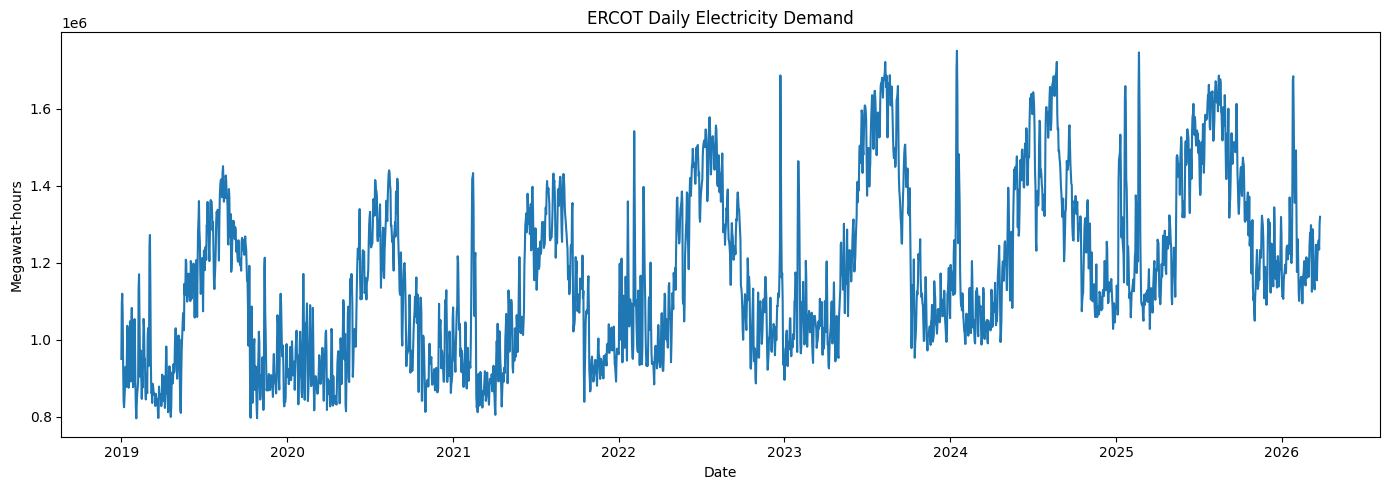

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(df_daily["period"], df_daily["demand"])
plt.title("ERCOT Daily Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Megawatt-hours")
plt.tight_layout()

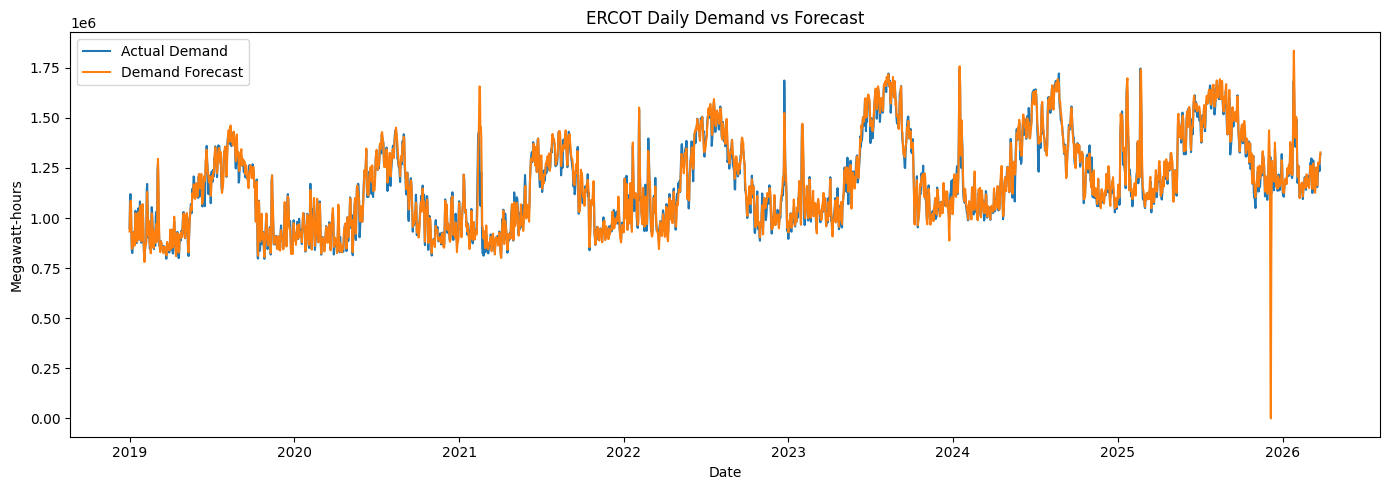

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(df_daily["period"], df_daily["demand"], label="Actual Demand")
plt.plot(df_daily["period"], df_daily["demand_forecast"], label="Demand Forecast")
plt.title("ERCOT Daily Demand vs Forecast")
plt.xlabel("Date")
plt.ylabel("Megawatt-hours")
plt.legend()
plt.tight_layout()

## 25. Final Summary

In [31]:
print("Final dataset summary")
print("---------------------")
print("Raw shape:", df_raw.shape)
print("Hourly shape:", df_hourly.shape)
print("Daily shape:", df_daily.shape)
print("Missing timestamps:", len(missing_timestamps))
print("Rows with remaining hourly nulls:", len(rows_with_nulls))
print("Incomplete daily records:", len(incomplete_days))

Final dataset summary
---------------------
Raw shape: (190154, 7)
Hourly shape: (63408, 4)
Daily shape: (2641, 7)
Missing timestamps: 0
Rows with remaining hourly nulls: 48
Incomplete daily records: 5


In [32]:
print("Final datasets:")
print("Hourly shape:", df_hourly.shape)
print("Daily shape:", df_daily.shape)

Final datasets:
Hourly shape: (63408, 4)
Daily shape: (2641, 7)
